# marv-hyena round 4: biology, and a null model

Round 3b ([RESEARCH_LOG.md](https://github.com/thebnbrkr/marv-hyena/blob/main/RESEARCH_LOG.md)) closed the two steps
round 3 lost, and the whole round-3 result set replicated **bit-identically** on different hardware. It also left one
method broken: integrated gradients at block 30's input fails its own completeness check at ~100%, because the funnel
kills the gradient one block back.

Round 4 answers three challenges to the round-3 findings — two from a biologist reading the lab notebook, one owed to
the literature review. **Every test here uses data already in the repo. No new downloads, E. coli throughout.**

| step | question | can it retract a finding? |
|---|---|---|
| R4.0 | Is the IG failure a sharp path? Then replace attribution with **causal** ablation at block 30's input (P18) | replaces a method |
| R4.1 | **Is block 0's word bank learned, or just architecture?** Random-weights null (P19) | **yes — findings 4, 10, 15, 16** |
| R4.2 | Does the copying circuit fire on **real genomic repeats**, or only our synthetic one? (P20) | **yes — finding 1** |
| R4.3 | Does Evo 2 represent **amino acids**, or only letters? (P21, P22) | new ground |

Ordered so the test that can invalidate existing findings runs first. Predictions P18–P22 are registered in
`PREDICTIONS.md` **before** this runs; do not edit them afterwards.

**Runtime:** A100 + High-RAM.

## 0. Setup

In [1]:
# GPU check (no torch import yet: the install below may change the torch version)
!nvidia-smi --query-gpu=name,memory.total,compute_cap --format=csv

name, memory.total [MiB], compute_cap
NVIDIA A100-SXM4-80GB, 81920 MiB, 8.0


In [2]:
# OPTIONAL: keep the ~15 GB Evo 2 weights on Google Drive so the next session skips the download.
# This must run BEFORE anything imports huggingface_hub / evo2.
USE_DRIVE = False

import os
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'
    os.makedirs(os.environ['HF_HOME'], exist_ok=True)
print('HF_HOME =', os.environ.get('HF_HOME', '(default ~/.cache/huggingface)'))

HF_HOME = (default ~/.cache/huggingface)


In [3]:
# Install Evo 2 + marv-hyena (~2-5 min). NO flash-attn: pip usually finds no prebuilt wheel for Colab's torch
# and compiles for hours. marv-hyena instead runs Evo 2's attention through PyTorch's built-in fused kernel
# (scaled_dot_product_attention), which is also fast on an A100 -- see marv_hyena/noflash.py.
# Colab runs Python 3.13, but every current evo2 release declares Python < 3.13, so a plain `pip install evo2`
# silently falls back to the old, incompatible 0.3.0. evo2 is pure Python, so force the current release.
# Colab also ships an empty `transformer-engine` package whose import crashes evo2; remove it (7B needs no TE).
!pip uninstall -y -q transformer-engine transformer_engine
!pip install -q --ignore-requires-python evo2==0.6.0
# Round 4 lives on a branch until it is merged: `main` has none of nullmodel/genome/codons,
# so cloning the default branch makes the import cell below fail. Set BRANCH='main' after merge.
BRANCH = 'round4-null-model-and-biology'
!rm -rf marv-hyena && git clone -q -b {BRANCH} https://github.com/thebnbrkr/marv-hyena.git
!pip install -q -r marv-hyena/requirements.txt openpyxl

import sys
sys.path.insert(0, '/content/marv-hyena')

# Fail loudly now rather than 20 minutes in, after the 15 GB model download.
import subprocess, os
print('branch:', subprocess.run(['git', '-C', 'marv-hyena', 'rev-parse', '--abbrev-ref', 'HEAD'],
                                capture_output=True, text=True).stdout.strip())
for m in ('nullmodel', 'genome', 'codons'):
    assert os.path.exists(f'marv-hyena/marv_hyena/{m}.py'), (
        f'{m}.py missing: wrong branch. Round 4 needs BRANCH={BRANCH!r}')
print('round-4 modules present')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 115.9 MB/s eta 0:00:00
branch: round4-null-model-and-biology
round-4 modules present


In [4]:
# Must run before anything imports evo2/vortex: lets Vortex import without flash-attn and turns flash attention off.
from marv_hyena import noflash
noflash.prepare()

import torch, vortex, evo2
from importlib.metadata import version
print('evo2', version('evo2'), '| vtx', version('vtx'))
assert version('evo2') >= '0.6.0', 'old evo2 installed: Runtime -> Disconnect and delete runtime, then rerun from the top'
print('torch', torch.__version__, '| cuda', torch.version.cuda, '| flash-attn package installed:', noflash.flash_attn_available())
print('GPU', torch.cuda.get_device_name(0), 'capability', torch.cuda.get_device_capability(0))
assert torch.cuda.get_device_capability(0)[0] >= 8, 'needs an Ampere+ GPU with bf16 (A100 / L4 / H100)'

evo2 0.6.0 | vtx 1.1.0
torch 2.11.0+cu130 | cuda 13.0 | flash-attn package installed: False
GPU NVIDIA A100-SXM4-80GB capability (8, 0)


In [5]:
# marv-hyena's own tests (a tiny CPU model that mirrors Vortex). Should say "60 passed".
!cd marv-hyena && python -m pytest -q

............................................................             [100%]
60 passed in 5.54s


In [6]:
# Data: the annotated E. coli K-12 genome from the evo2 repo
import os, urllib.request
os.makedirs('data', exist_ok=True)
EVO2_RAW = 'https://raw.githubusercontent.com/ArcInstitute/evo2/main/notebooks'
GENOME = 'data/NC_000913.gb'
if not os.path.exists(GENOME):
    urllib.request.urlretrieve(f'{EVO2_RAW}/sparse_autoencoder/NC_000913.gb', GENOME)

import marv_hyena as mh
from marv_hyena.probes import load_sequence
genome = load_sequence(GENOME)
print(f'E. coli genome: {len(genome):,} letters')

E. coli genome: 4,641,652 letters


In [7]:
# Load Evo 2 7B (downloads ~15 GB the first time)
import time
MODEL_NAME = 'evo2_7b'
t0 = time.time()
hm = mh.HyenaModel.load(MODEL_NAME)
print(f'loaded in {time.time()-t0:.0f}s')
print(hm.describe())
RESULTS = {}

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Found complete file in repo: evo2_7b.pt


/usr/local/lib/python3.13/dist-packages/evo2/models.py:294: UserWarning: Transformer Engine not installed. Falling back to bf16 projections (use_fp8_input_projections=False). 
  warnings.warn(


  0%|          | 0/32 [00:00<?, ?it/s]

 12%|█▎        | 4/32 [00:00<00:01, 26.17it/s]

100%|██████████| 32/32 [00:00<00:00, 124.85it/s]


Extra keys in state_dict: {'blocks.9.mixer.mixer.filter.t', 'blocks.13.mixer.mixer.filter.t', 'blocks.25.projections._extra_state', 'blocks.19.projections._extra_state', 'blocks.24.mixer.dense._extra_state', 'blocks.23.projections._extra_state', 'blocks.20.mixer.mixer.filter.t', 'blocks.16.projections._extra_state', 'blocks.3.mixer.attn._extra_state', 'blocks.12.projections._extra_state', 'blocks.30.mixer.mixer.filter.t', 'blocks.23.mixer.mixer.filter.t', 'blocks.28.projections._extra_state', 'blocks.30.projections._extra_state', 'blocks.9.projections._extra_state', 'blocks.6.projections._extra_state', 'blocks.27.mixer.mixer.filter.t', 'blocks.22.projections._extra_state', 'blocks.14.projections._extra_state', 'blocks.29.projections._extra_state', 'blocks.10.mixer.attn._extra_state', 'blocks.5.projections._extra_state', 'unembed.weight', 'blocks.2.projections._extra_state', 'blocks.24.mixer.attn._extra_state', 'blocks.17.mixer.dense._extra_state', 'blocks.31.mixer.dense._extra_state', 

In [8]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json, random
from marv_hyena import diagnostics, motifs, interface, nullmodel, genome as gen, codons
from marv_hyena.checks import run_smoke_checks
from marv_hyena.experiments import make_conditions
from marv_hyena.intervene import mean_ablate, mean_writes

seq = genome[100_000:104_096]
assert run_smoke_checks(hm, seq), 'smoke checks failed: stop here'
HEALTH_SEQ = genome[300_000:304_096]
BOTTLENECK = diagnostics.find_bottlenecks(hm, seq, [1000, 2000, 4095])
print('bottleneck:', BOTTLENECK, '| baseline health:', diagnostics.health(hm, HEALTH_SEQ))
L = BOTTLENECK[0] if BOTTLENECK else hm.n_blocks - 2   # evo2_7b: block 30
print('interface block:', L)

# Round 3's load-bearing set, re-found on this run: family ablations must keep these on.
lb = diagnostics.find_load_bearing(hm, HEALTH_SEQ)
LOAD_BEARING = sorted({r['block'] for r in lb if r['broken']})
print('load-bearing mixers:', LOAD_BEARING)

RESULTS = {'bottleneck': BOTTLENECK, 'interface_block': L, 'load_bearing': lb,
           'load_bearing_blocks': LOAD_BEARING}

# One reference we come back to: any experiment that scrambles weights must put
# them back, and this is what "put them back" is checked against.
REF_LOGITS = hm.logits(HEALTH_SEQ).clone()

[PASS] embed + sum(writes) == final residual  rel_err=8.21e-06
[PASS] trace rows sum to real logit diff  sum=+8.541 actual=+8.505
[PASS] distance bands reconstruct block 14 (se)  rel_err=3.98e-03
[PASS] distance bands reconstruct block 15 (mr)  rel_err=3.41e-03
[PASS] distance bands reconstruct block 16 (li)  rel_err=2.66e-03
[PASS] block 0 receptive field small enough to enumerate  measured 9 letters
[PASS] hooks removed after intervention  
[PASS] mean-ablating LI mixers changes the output  

8/8 checks passed
bottleneck: [30] | baseline health: {'health_acc': 0.6959707140922546, 'health_lp': -0.6843298673629761, 'broken': False}
interface block: 30
load-bearing mixers: [0, 1, 4, 9, 29, 30]


## R4.0 Why integrated gradients failed, and what replaces it (P18)

R3.4 attributed **zero** where `f` really moves by up to 5.9, at all six positions. Two candidate causes: the
function is near-discontinuous along the integration path (so 32 midpoint samples step over it), or the attribution
code is wrong. One forward-only scan of `f` along the path settles it. No autograd, no gradients — just `f` at 512
points between the embedding-only baseline and the real residual entering block 30.

{'gene': [204001, 305848, 399989], 'intergenic': [209630, 303820, 399582]}


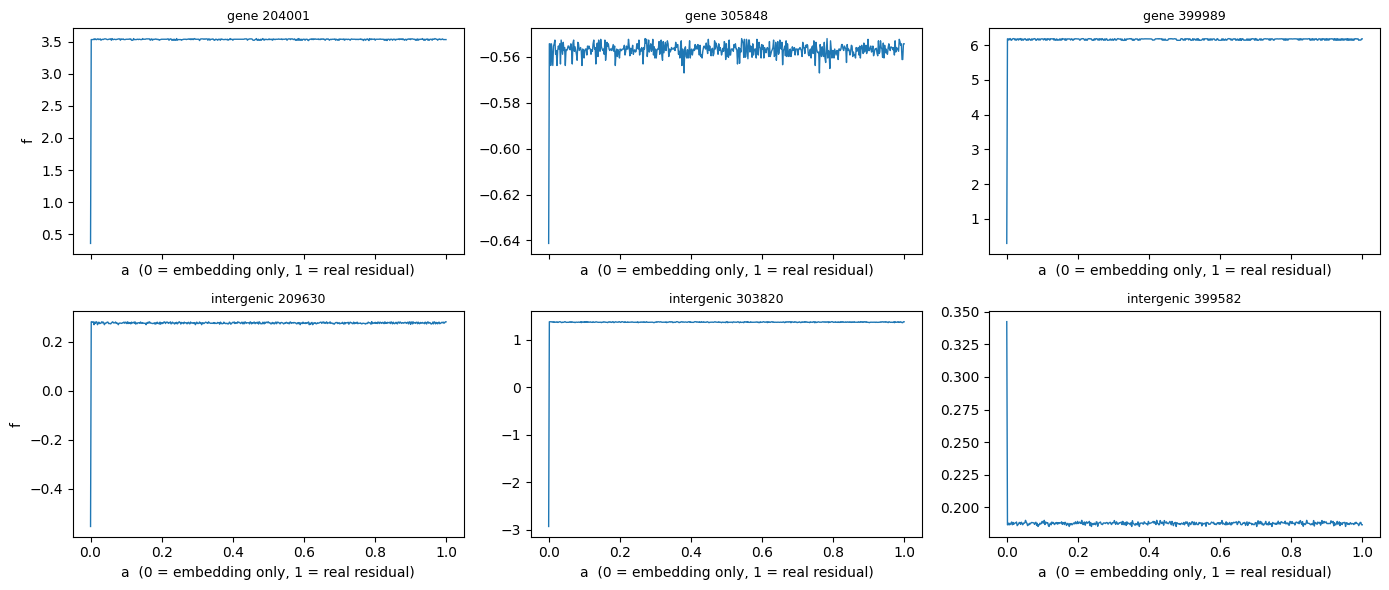

    region    pos    range  max_step_frac_of_range  path_frac_for_80pct_variation
      gene 204001 3.188151                0.995099                       0.251953
      gene 305848 0.089193                0.974453                       0.458984
      gene 399989 5.894206                0.998675                       0.349609
intergenic 209630 0.834961                0.999220                       0.419922
intergenic 303820 4.317708                0.999397                       0.277344
intergenic 399582 0.157227                0.991718                       0.429688

P18 predicted: some single step >= 25% of the range, and >=80% of variation in <10% of the path
  max single step   >= 0.25 : True
  80% of variation in <10%  : False


In [9]:
# f(e + a*(u - e)) on a dense grid. Forward passes only.
import torch

@torch.no_grad()
def path_scan(hm, seq, index, layer, steps=512, target=None):
    target = target or seq[index]
    pos = index - 1
    ids = hm.ids(seq[:index])
    store = {}
    h1 = hm.block(layer).register_forward_pre_hook(lambda m, a: store.__setitem__('u', a[0].detach()))
    h2 = hm.model.embedding_layer.register_forward_hook(lambda m, i, o: store.__setitem__('e', o.detach()))
    try:
        hm.model(ids)
    finally:
        h1.remove(); h2.remove()
    u, e = store['u'], store['e'].to(store['u'].device)
    direction, tw = mh.logit_direction(hm, target)
    tw = tw.to(hm.device)
    out = []
    for s in range(steps + 1):
        a = s / steps
        x = e + a * (u - e)
        out.append(float((interface._tail(hm, x, layer)[0, pos].float() * tw).sum()))
    return np.array(out)

big = mh.genbank_track(GENOME, 200_000, 400_000)
POSITIONS = {'gene': [204001, 305848, 399989], 'intergenic': [209630, 303820, 399582]}
print(POSITIONS)

scan_rows = []
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for k, (region, ps) in enumerate(POSITIONS.items()):
    for j, p in enumerate(ps):
        f = path_scan(hm, genome[p - 4000:p + 1], 4000, L)
        rng_ = f.max() - f.min()
        step = np.abs(np.diff(f))
        # what fraction of the path carries 80% of the total variation?
        order = np.argsort(step)[::-1]
        cum = np.cumsum(step[order]) / max(step.sum(), 1e-12)
        frac_path = (np.searchsorted(cum, 0.80) + 1) / len(step)
        scan_rows.append({'region': region, 'pos': p, 'f_min': float(f.min()), 'f_max': float(f.max()),
                          'range': float(rng_), 'max_step_frac_of_range': float(step.max() / max(rng_, 1e-12)),
                          'path_frac_for_80pct_variation': float(frac_path)})
        axes[k][j].plot(np.linspace(0, 1, len(f)), f, lw=1)
        axes[k][j].set_title(f'{region} {p}', fontsize=9)
        axes[k][j].set_xlabel('a  (0 = embedding only, 1 = real residual)')
axes[0][0].set_ylabel('f'); axes[1][0].set_ylabel('f')
plt.tight_layout(); plt.show()

scan = pd.DataFrame(scan_rows)
RESULTS['path_scan'] = scan_rows
print(scan[['region', 'pos', 'range', 'max_step_frac_of_range', 'path_frac_for_80pct_variation']].to_string(index=False))
print()
print('P18 predicted: some single step >= 25% of the range, and >=80% of variation in <10% of the path')
print('  max single step   >= 0.25 :', bool((scan.max_step_frac_of_range >= 0.25).any()))
print('  80% of variation in <10%  :', bool((scan.path_frac_for_80pct_variation < 0.10).all()))

### R4.0b The causal replacement

Whatever the scan shows, the question "what does block 30 read?" is answerable without gradients: mean-ablate each
write **entering** block 30 and measure what the logits do. Total effect, no completeness assumption, no autograd,
no inference-tensor workaround.

In [10]:
# Causal attribution at block 30's input: ablate each incoming write, one at a time.
rows = []
for region, ps in POSITIONS.items():
    for p in ps:
        s = genome[p - 4000:p + 1]
        ids = hm.ids(s)
        base = hm.logits(ids)[-1].float()
        tgt = mh.arch.base_id(genome[p])
        base_score = float(base[tgt] - base[[mh.arch.base_id(b) for b in 'ACGT' if b != genome[p]]].mean())
        for b in range(L):
            for part in ('mixer', 'mlp'):
                with mean_ablate(hm, mean_writes(hm, ids, [(b, part)])):
                    lg = hm.logits(ids)[-1].float()
                sc = float(lg[tgt] - lg[[mh.arch.base_id(x) for x in 'ACGT' if x != genome[p]]].mean())
                rows.append({'region': region, 'pos': p, 'block': b, 'kind': hm.kind(b), 'part': part,
                             'delta': sc - base_score})

ca = pd.DataFrame(rows)
RESULTS['causal_interface'] = rows
top = (ca.assign(a=ca.delta.abs()).groupby(['block', 'kind', 'part']).a.mean()
         .sort_values(ascending=False).head(15))
print('mean |change in the letter\'s logit advantage| when this write is removed:')
print(top.to_string())
by_kind = ca.assign(a=ca.delta.abs()).groupby('kind').a.mean().sort_values(ascending=False)
print()
print('by operator type:'); print(by_kind.to_string())

mean |change in the letter's logit advantage| when this write is removed:
block  kind  part 
0      se    mixer    2.707513
2      li    mlp      2.555528
9      li    mixer    2.509332
29     mr    mlp      2.386163
             mixer    2.385417
28     se    mlp      2.384315
1      mr    mixer    2.338257
4      se    mixer    2.221975
1      mr    mlp      1.757473
5      mr    mixer    1.493964
10     attn  mixer    1.427667
28     se    mixer    0.930474
27     li    mlp      0.697374
23     li    mixer    0.648180
2      li    mixer    0.607937

by operator type:
kind
mr      0.760409
se      0.688549
li      0.655015
attn    0.411337


## R4.1 Is block 0 learned, or is it the architecture? (P19)

Block 0 gives detector channels to all 64 three-letter words, median 46, mean 45.2 — a suspiciously **flat**
distribution, and flat is what an untrained gated 9-letter convolution might also produce.

`nullmodel.random_weights(..., mode="shuffle")` permutes each weight tensor. The multiset of weights is preserved
exactly — same mean, variance, every moment — so only the learned *arrangement* is destroyed. Anything that survives
is architecture.

**This cell can retract findings 4, 10, 15 and 16.** Registered expectation (P19): the null also produces a flat
bank.

In [11]:
# Trained block 0, then the same enumeration on scrambled weights.
def word_profile(md_):
    ranks = motifs.rank_all_words(md_, length=3)
    d = {r['word']: r['controlled'] for r in ranks}
    # same definition round 3 used for the 724 figure, so the two are comparable
    dead = int((md_.position_importance.sum(0) < 1e-6).sum())
    return ranks, d, dead

md_trained = motifs.enumerate_block0(hm, keep_all=True)
ranks_t, words_t, dead_t = word_profile(md_trained)
summ = {'trained': nullmodel.word_count_summary(ranks_t)}
print('trained :', summ['trained'], '| dead channels:', dead_t)

null_words = []
for s in (0, 1, 2):
    with nullmodel.random_weights(hm, 0, mode='shuffle', seed=s) as n:
        md_null = motifs.enumerate_block0(hm, keep_all=True)
    ranks_n, words_n, dead_n = word_profile(md_null)
    summ[f'shuffled_seed{s}'] = nullmodel.word_count_summary(ranks_n)
    null_words.append(words_n)
    print(f'shuffled seed {s} ({n} tensors):', summ[f'shuffled_seed{s}'], '| dead:', dead_n)

# the weights must be back
chk = nullmodel.verify_restored(hm, HEALTH_SEQ, REF_LOGITS)
print('\nweights restored:', chk)
assert chk['restored'], 'block 0 was not restored; every later number is invalid'

RESULTS['block0_null'] = {'summary': summ, 'trained_words': words_t,
                          'null_words': null_words, 'dead_trained': dead_t}

trained : {'n_words': 64, 'mean': 45.15625, 'median': 46.0, 'std': 12.655555536502536, 'min': 6.0, 'max': 65.0, 'cv': 0.28026143748656135, 'max_over_median': 1.4130434782608696} | dead channels: 724
shuffled seed 0 (8 tensors): {'n_words': 64, 'mean': 0.0, 'median': 0.0, 'std': 0.0, 'min': 0.0, 'max': 0.0, 'cv': nan, 'max_over_median': nan} | dead: 5
shuffled seed 1 (8 tensors): {'n_words': 64, 'mean': 0.0, 'median': 0.0, 'std': 0.0, 'min': 0.0, 'max': 0.0, 'cv': nan, 'max_over_median': nan} | dead: 3
shuffled seed 2 (8 tensors): {'n_words': 64, 'mean': 0.0, 'median': 0.0, 'std': 0.0, 'min': 0.0, 'max': 0.0, 'cv': nan, 'max_over_median': nan} | dead: 7

weights restored: {'max_abs_logit_diff': 0.0, 'restored': True}


trained  : median 46  cv 0.280  max/median 1.41
shuffled : median 0  cv nan

P19 predicted the null looks like the trained model:
  cv within 50%          : False
  median within 2x of 46 : False

If both are True, block 0 findings describe the ARCHITECTURE, not Evo 2.


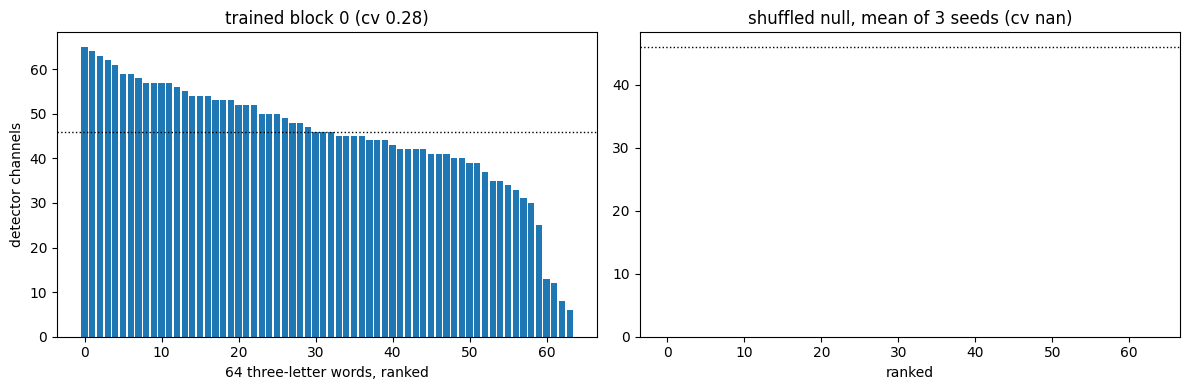

In [12]:
# The comparison that decides P19.
t = summ['trained']
nulls = [summ[k] for k in summ if k.startswith('shuffled')]
null_cv = float(np.mean([n['cv'] for n in nulls]))
null_med = float(np.mean([n['median'] for n in nulls]))

print(f"trained  : median {t['median']:.0f}  cv {t['cv']:.3f}  max/median {t['max_over_median']:.2f}")
print(f"shuffled : median {null_med:.0f}  cv {null_cv:.3f}")
print()
print('P19 predicted the null looks like the trained model:')
print(f"  cv within 50%          : {abs(null_cv - t['cv']) <= 0.5 * t['cv']}")
print(f"  median within 2x of 46 : {23 <= null_med <= 92}")
print()
print('If both are True, block 0 findings describe the ARCHITECTURE, not Evo 2.')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
words = sorted(words_t, key=lambda w: -words_t[w])
ax[0].bar(range(64), [words_t[w] for w in words], width=.8)
ax[0].set_title(f'trained block 0 (cv {t["cv"]:.2f})'); ax[0].set_xlabel('64 three-letter words, ranked')
ax[0].set_ylabel('detector channels')
ax[1].bar(range(64), [np.mean([nw[w] for nw in null_words]) for w in
                      sorted(null_words[0], key=lambda w: -np.mean([nw[w] for nw in null_words]))], width=.8)
ax[1].set_title(f'shuffled null, mean of 3 seeds (cv {null_cv:.2f})'); ax[1].set_xlabel('ranked')
for a in ax: a.axhline(46, color='k', ls=':', lw=1)
plt.tight_layout(); plt.show()

## R4.2 Does the copying circuit fire on real repeats? (P20)

Rounds 1–3 showed attention copies a **random** 200-letter insert. The objection: that is string matching, not
biology, and the synthetic probe may recruit machinery real DNA rarely touches.

Same experiment, three arms at identical geometry — a real E. coli repeat (rRNA operons, IS elements), the same
repeat with its letters shuffled, and a random insert. The statistic is the **retrieval gain**,
`second_lp − first_lp`: a real rRNA copy already scores well on its *first* appearance because the model knows rRNA,
so only the gain isolates what retrieval added.

In [13]:
fams = gen.find_repeat_families(GENOME, types=('rRNA', 'mobile_element'), min_copies=2, min_len=250)
for f in fams[:12]:
    print(f)
assert fams, 'no repeat families found; check the GenBank annotations'

background = genome[1_500_000:1_560_000]
probe_list = []
for f in fams[:4]:
    probe_list += gen.repeat_probes(background, f, gaps=(1000, 10000), insert_len=200, lead=1000, seed=0)
print(f'\n{len(probe_list)} probes: ',
      pd.Series([p.arm for p in probe_list]).value_counts().to_dict())

RepeatFamily('16S ribosomal RNA', rRNA, 7 copies, 1542 bp, identity 0.995)

6 probes:  {'real': 2, 'shuffled': 2, 'random': 2}


In [14]:
conds = make_conditions(hm, exclude_blocks=LOAD_BEARING)
rep_rows = gen.run_repeat_test(hm, probe_list, conditions=conds)
RESULTS['repeat_test'] = rep_rows

summ_rep = pd.DataFrame(gen.summarize_repeat_test(rep_rows))
piv = summ_rep.pivot_table(index=['condition'], columns=['arm', 'gap'], values='retrieval_gain')
print('RETRIEVAL GAIN (second_lp - first_lp):'); print(piv.round(3).to_string())
print()
keep = summ_rep.pivot_table(index=['condition'], columns=['arm', 'gap'], values='gain_kept')
print('FRACTION OF THE UNABLATED GAIN KEPT:'); print(keep.round(3).to_string())
print()
first = summ_rep.pivot_table(index=['condition'], columns=['arm'], values='first_lp')
print('FIRST-COPY log-prob (should barely move: it cannot use retrieval):')
print(first.round(3).to_string())

RETRIEVAL GAIN (second_lp - first_lp):
arm                       random          real        shuffled       
gap                        1000   10000  1000   10000    1000   10000
condition                                                            
-attn                      0.007 -0.008 -0.121 -0.050    0.013  0.011
-li (keep L0,1,4,9,29,30)  0.983  0.413  0.147  0.094    0.997  0.381
-mr (keep L0,1,4,9,29,30)  1.397  1.402  0.050  0.043    1.388  1.394
-se (keep L0,1,4,9,29,30)  1.030  1.270  0.168  0.150    0.900  1.197
none                       1.421  1.425  0.028  0.027    1.392  1.386

FRACTION OF THE UNABLATED GAIN KEPT:
arm                       random          real        shuffled       
gap                        1000   10000  1000   10000    1000   10000
condition                                                            
-attn                      0.005 -0.006 -4.382 -1.879    0.009  0.008
-li (keep L0,1,4,9,29,30)  0.692  0.290  5.320  3.500    0.716  0.275
-mr (keep L0,

In [15]:
# P20's decision numbers.
real = summ_rep[(summ_rep.arm == 'real')]
base_gain = float(real[(real.condition == 'none') & (real.gap == 1000)].retrieval_gain.iloc[0])
attn = real[real.condition == '-attn']
attn_kept = float(attn.gain_kept.mean())
d_first = float(attn.first_lp.mean() - real[real.condition == 'none'].first_lp.mean())
print(f'real arm, gap 1000, unablated retrieval gain : {base_gain:+.3f} nats   (P20 wanted >= 0.5)')
print(f'-attn keeps                                   : {attn_kept:.1%}        (P20 wanted <= 30% kept)')
print(f'-attn moves first-copy log-prob by            : {d_first:+.3f} nats   (P20 wanted |d| <= 0.15)')
print()
rnd = summ_rep[(summ_rep.arm == 'random') & (summ_rep.condition == 'none') & (summ_rep.gap == 1000)]
print(f'random arm gain {float(rnd.retrieval_gain.iloc[0]):+.3f} -> real/random ratio '
      f'{base_gain / float(rnd.retrieval_gain.iloc[0]):.2f}  (P20 wanted within 2x)')

real arm, gap 1000, unablated retrieval gain : +0.028 nats   (P20 wanted >= 0.5)
-attn keeps                                   : -313.1%        (P20 wanted <= 30% kept)
-attn moves first-copy log-prob by            : -0.016 nats   (P20 wanted |d| <= 0.15)

random arm gain +1.421 -> real/random ratio 0.02  (P20 wanted within 2x)


## R4.3 Does Evo 2 represent amino acids? (P21, P22)

The genetic code is redundant, which gives a clean controlled comparison. At one codon, change the **third** letter
two ways:

- **silent** `ATT → ATC` (both isoleucine)
- **missense** `ATT → ATG` (isoleucine → methionine)

Same site, same codon position, same edit distance, same neighbours. The only difference is whether the protein
changed. If the model only does nucleotide statistics the two should be comparable; if it represents the protein, the
missense one should disturb it more — and the block where they part company is where the genetic code gets applied.

Premature stops are excluded here (they are a much bigger biological event) and get their own arm below.

In [16]:
track = mh.genbank_track(GENOME, 200_000, 260_000)
sites = codons.wobble_sites(track, allow_stop=False, min_spacing=120, max_sites=120)
print(f'{len(sites)} wobble sites')
print(pd.Series([f'{s.codon}->{s.syn_codon}/{s.nonsyn_codon} ({s.aa}->{s.nonsyn_aa})'
                 for s in sites[:8]]).to_string())

seq_window = track.seq
tr_rows = codons.translation_test(hm, seq_window, sites, window=4096, span=24, downstream_span=200)
RESULTS['translation'] = tr_rows
tr = pd.DataFrame(tr_rows)
s = codons.summarize_translation(tr_rows)
RESULTS['translation_summary'] = s
print()
print(s)

120 wobble sites
0    CAG->CAA/CAC (Q->H)
1    TTC->TTT/TTA (F->L)
2    TTG->TTA/TTC (L->F)
3    AAA->AAG/AAC (K->N)
4    AAC->AAT/AAA (N->K)
5    GAA->GAG/GAC (E->D)
6    AAA->AAG/AAC (K->N)
7    ATT->ATA/ATG (I->M)

{'n': 119, 'n_usable': 48, 'mean_syn_effect': -0.7141745992067481, 'mean_nonsyn_effect': -1.535634489620433, 'nonsyn_more_disruptive_frac': 0.6890756302521008, 'median_effect_ratio': 1.3188948567471654, 'modal_peak_block': 11}


missense more disruptive than silent, SAME site : 68.9%   (P21 wanted >= 65%)   <- decides P21
sites: 119 total, 48 usable for a ratio
median effect ratio (missense / silent)         : 1.319   (P21 wanted >= 1.20)
modal block where the two arms diverge most     : 11   (P21 wanted > 7)


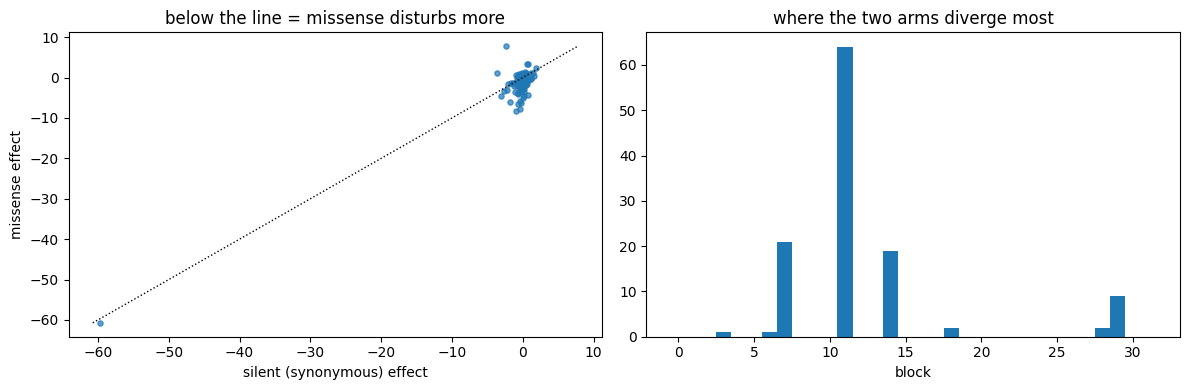

In [17]:
# P21's decision numbers.
# The paired sign test decides P21: no threshold, no ratio, every site counts.
print(f"missense more disruptive than silent, SAME site : {s['nonsyn_more_disruptive_frac']:.1%}"
      f"   (P21 wanted >= 65%)   <- decides P21")
print(f"sites: {s['n']} total, {s['n_usable']} usable for a ratio")
if s['n_usable'] >= 20:
    print(f"median effect ratio (missense / silent)         : {s['median_effect_ratio']:.3f}"
          f"   (P21 wanted >= 1.20)")
else:
    print("median effect ratio: NOT REPORTED (n_usable < 20; widen the track)")
print(f"modal block where the two arms diverge most     : {s['modal_peak_block']}"
      f"   (P21 wanted > 7)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(tr.syn_effect, tr.nonsyn_effect, s=14, alpha=.7)
lim = [min(tr.syn_effect.min(), tr.nonsyn_effect.min()), max(tr.syn_effect.max(), tr.nonsyn_effect.max())]
ax[0].plot(lim, lim, 'k:', lw=1)
ax[0].set_xlabel('silent (synonymous) effect'); ax[0].set_ylabel('missense effect')
ax[0].set_title('below the line = missense disturbs more')
ax[1].hist(tr.peak_divergence_block.dropna(), bins=np.arange(-0.5, hm.n_blocks + 0.5))
ax[1].set_xlabel('block'); ax[1].set_title('where the two arms diverge most')
plt.tight_layout(); plt.show()

In [18]:
# P22: premature stops against ordinary missense, at matched sites.
sites_stop = codons.wobble_sites(track, allow_stop=True, min_spacing=120, max_sites=120)
nonsense = [x for x in sites_stop if x.is_nonsense]
print(f'{len(nonsense)} nonsense sites')
if nonsense:
    ns_rows = codons.translation_test(hm, seq_window, nonsense, window=4096, span=24, downstream_span=200)
    RESULTS['nonsense'] = ns_rows
    ns = pd.DataFrame(ns_rows)
    ns_s = codons.summarize_translation(ns_rows)
    RESULTS['nonsense_summary'] = ns_s
    print(f"usable nonsense sites: {ns_s['n_usable']} of {ns_s['n']}")
    if ns_s['n_usable'] < 20:
        print('P22 UNTESTABLE: fewer than 20 usable nonsense sites. Widen the track.')
    else:
        # compare the two arms' own disruption, not a ratio of ratios
        e_stop = float(np.median(ns[ns.usable].nonsyn_effect))
        e_miss = float(np.median(tr[tr.usable].nonsyn_effect))
        print(f'median downstream effect, premature stop : {e_stop:+.3f}')
        print(f'median downstream effect, missense       : {e_miss:+.3f}')
        print(f'stop / missense                          : {e_stop / e_miss:.3f}   (P22 wanted >= 1.5)')
else:
    print('no nonsense sites in this window; widen the track')

11 nonsense sites
usable nonsense sites: 2 of 11
P22 UNTESTABLE: fewer than 20 usable nonsense sites. Widen the track.


## Save

`results_round4.json` goes next to the executed notebook in `results/round4/`. Record the outcomes in
`PREDICTIONS.md` **as they came out**, then write the round-4 entry in `RESEARCH_LOG.md`.

In [19]:
import json

def jsonable(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.ndarray,)): return o.tolist()
    if isinstance(o, (np.bool_,)): return bool(o)
    return str(o)

with open('results_round4.json', 'w') as fh:
    json.dump(RESULTS, fh, default=jsonable, indent=1)
print('wrote results_round4.json', os.path.getsize('results_round4.json'), 'bytes')
print('keys:', list(RESULTS))

try:
    from google.colab import files
    files.download('results_round4.json')
except Exception as e:
    print('(download skipped:', e, ')')

wrote results_round4.json 116687 bytes
keys: ['bottleneck', 'interface_block', 'load_bearing', 'load_bearing_blocks', 'path_scan', 'causal_interface', 'block0_null', 'repeat_test', 'translation', 'translation_summary', 'nonsense', 'nonsense_summary']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>